# BM4322 Genomic Signal Processing – Assignment 1
## Promoter Discovery in Bacteria

**Index No.:** 220472T
**Accession:** ASM2286996v1 – *Salmonella enterica* subsp. *enterica* strain PartC-Senterica-RM8376

In this notebook I run my assignment step by step. The real work is done by the functions in the
`.py` files in this folder (one file for each step), and here I call them in order, show the
results and explain what I did. **Kernel → Restart & Run All** gives exactly the same results as
`python main.py` and as my report (about 15 seconds).

| File | What it does |
|---|---|
| `config.py` | file paths and all the settings (numbers) I used |
| `helpers.py` | printing, reading/writing FASTA files, translating DNA to protein |
| `step0_data.py` | Step 0: choose the 1000 genes and cut the 103-base sequences |
| `step0_methionine_check.py` | Step 0: check the start codon (Methionine) |
| `q1_local_search.py` | Q1: Smith–Waterman local search for `WWWW` |
| `q2_consecutive_w.py` | Q2: number of consecutive Ws |
| `q3_ppm.py` | Q3: position probability matrix (PPM) |
| `q4_statistical_alignment.py` | Q4: statistical alignment with the PPM |
| `q5_comparison.py` | Q5: comparison of the two searches + shuffled control |
| `plots.py` | the figures of my report |
| `summary.py` | collects all my numbers into `results/summary.json` |

In [1]:
# I run this notebook from the code folder, so Python can import my .py files directly.
%matplotlib inline
import os
import numpy as np
import pandas as pd

# stop with a clear message if the notebook was started from another folder
if not os.path.exists("config.py"):
    raise FileNotFoundError("Open this notebook from the code folder (the folder with config.py), "
                            "otherwise Python cannot find my .py files.")

import config
import helpers
import plots
from step0_data import run_step0
from step0_methionine_check import run_methionine_check
from q1_local_search import run_q1, local_search
from q2_consecutive_w import run_q2
from q3_ppm import run_q3
from q4_statistical_alignment import run_q4, stat_align
from q5_comparison import run_q5
from summary import build_summary

helpers.clear_log()
helpers.make_result_folders()
print("Genome file  :", os.path.relpath(config.GENOME_FILE))
print("Table file   :", os.path.relpath(config.TABLE_FILE))
print("Results go to:", os.path.relpath(config.RESULTS_DIR))

Genome file  : ../data/GCA_022869965.1_ASM2286996v1_genomic.fna
Table file   : ../data/ncbi_dataset.tsv
Results go to: ../results


## Step 0 – Choosing the genes and cutting the sequences

The genome FASTA is only a long string of A, C, G and T, so I need the protein table (.tsv) to know
where each gene starts (`Begin`) and on which strand it is (`Orientation`). I take the first 1000
protein-coding genes on the **+ (sense) strand** in the order they appear on the chromosome.

The table counts positions from 1, but Python counts from 0. The start codon of a gene is at
`Begin … Begin+2`, so in Python I cut `genome[Begin-101 : Begin+2]`: **100 bases upstream + the
3-base start codon = 103 bases**. Positions are given relative to the start codon (−1 is the base
just before it, −100 the farthest).

In [2]:
d = run_step0()
d["genes"][["Locus tag", "Symbol", "Name", "Begin", "End", "Protein length"]].head()

STEP 0 - data and sequence extraction
Genome CP064385.1: 4,857,492 bp, GC content 52.22%
Protein table: 4850 genes, types: {'protein-coding': 4612, 'pseudogene': 113, 'tRNA': 86, 'rRNA': 22, 'ncRNA': 13, 'other': 2, 'antisense_RNA': 1, 'RNase_P_RNA': 1}
On the chromosome: 4733 genes (+ strand 2280, - strand 2453)
Protein-coding genes on the + strand: 2153
I use the first 1000: murJ (starts at 571) to acpT (ends at 2496884)
A/T content of the upstream regions: 54.9% (whole genome 47.8%)


,Locus tag,Symbol,Name,Begin,End,Protein length
0,IUJ38_RS00010,murJ,murein biosynthesis integral membrane protein ...,571,2106,511.0
1,IUJ38_RS00030,flgB,flagellar basal body rod protein FlgB,3816,4232,138.0
2,IUJ38_RS00035,flgC,flagellar basal body rod protein FlgC,4236,4640,134.0
3,IUJ38_RS00040,flgD,flagellar hook assembly protein FlgD,4652,5350,232.0
4,IUJ38_RS00045,flgE,flagellar hook protein FlgE,5377,6588,403.0


In [3]:
# one example: the first gene, murJ
k = 0
seq = d["sequences"][k]
print("gene:", d["genes"].loc[k, "Symbol"], "   Begin =", d["genes"].loc[k, "Begin"])
print("100 upstream bases:", seq[:100])
print("start codon       :", seq[100:])

gene: murJ    Begin = 571
100 upstream bases: TCAGGCGCGGTGATACAGCCGGATACGGCAGAAGTTGCGTTATCCGGTCGATGGATCAGCCATGCAGGAGTTTTACGCCAGGGTCTGGAATACAAAAGAA
start codon       : ATG


### Checking my code with Methionine

If my positions are right, the last 3 bases must be a start codon, which codes for Methionine (M).
I first check some well-known genes, then all 1000. GTG and TTG are also normal start codons in
bacteria (they are read as Methionine at the start of a gene). I also translate every whole gene and
compare the protein length with the table.

In [4]:
met = run_methionine_check(d)
met["known_genes"]


Methionine check on known genes (last 12 upstream bases + start codon):
  murJ  aatacaaaagaa ATG -> MNLLKSLAAV...  length 511 aa (table 511)
  rpoD  ggataccgtctt ATG -> MEQNPQSQLK...  length 615 aa (table 615)
  crp   ggataaccgcgc ATG -> MVLGKPQTDP...  length 210 aa (table 210)
  hns   gagattactaca ATG -> MSEALKILNN...  length 137 aa (table 137)
  fis   gctgacagaact ATG -> MFEQRVNSDV...  length 98 aa (table 98)
  ompC  aaggcatataaa ATG -> MKKVVVLSAV...  length 372 aa (table 372)
  hilA  tacactattatc ATG -> MPHFNPVPVS...  length 553 aa (table 553)
  tolC  tcacaacaagga ATG -> MQMKKLLPIL...  length 491 aa (table 491)
  trpA  aggggaaatctg ATG -> MERYENLFAQ...  length 268 aa (table 268)


  not matching the table: IUJ38_RS08235 IS3 family transposase
Start codons of the 1000 genes: {'ATG': 912, 'GTG': 66, 'TTG': 18, 'ATT': 2, 'CTG': 2}
Start codon read as Methionine: 1000/1000
Whole CDS translates to the protein length in the table: 999/1000


,gene,locus_tag,last12_upstream_and_start_codon,translated_N_terminus,protein_length_table,translated_length,check
0,murJ,IUJ38_RS00010,aatacaaaagaa ATG,MNLLKSLAAV,511,511,OK
1,rpoD,IUJ38_RS10490,ggataccgtctt ATG,MEQNPQSQLK,615,615,OK
2,crp,IUJ38_RS11775,ggataaccgcgc ATG,MVLGKPQTDP,210,210,OK
3,hns,IUJ38_RS02980,gagattactaca ATG,MSEALKILNN,137,137,OK
4,fis,IUJ38_RS11365,gctgacagaact ATG,MFEQRVNSDV,98,98,OK
5,ompC,IUJ38_RS01830,aaggcatataaa ATG,MKKVVVLSAV,372,372,OK
6,hilA,IUJ38_RS08775,tacactattatc ATG,MPHFNPVPVS,553,553,OK
7,tolC,IUJ38_RS10355,tcacaacaagga ATG,MQMKKLLPIL,491,491,OK
8,trpA,IUJ38_RS02860,aggggaaatctg ATG,MERYENLFAQ,268,268,OK


## Q1 – Standard local search for the intact query `WWWW`

W means A or T. I use the **Smith–Waterman** local alignment because I am looking for a short query
anywhere inside a longer sequence. Scores: +1 when the base fits the query letter, −1 when it does
not, and −2 for a gap (the values from the module code). The query is **intact** when all four Ws
match with no gap, which gives the highest possible score, 4. If a sequence has many intact matches,
the search reports the first one (the one nearest the 5′ end).

First I try it on one sequence:

In [5]:
best, start = local_search(d["upstream"][0], config.QUERY)
print("best score   :", best, "(4 = all of WWWW matched = intact)")
print("hit starts at index", start, "-> position", -helpers.upstream_position(start))
print("matched bases:", d["upstream"][0][start:start + 4])

best score   : 4.0 (4 = all of WWWW matched = intact)
hit starts at index 39 -> position -61
matched bases: TTAT


In [6]:
q1 = run_q1(d)


Q1 - standard local search for WWWW


Best score distribution: {4: 995, 3: 5}
Genes with an intact WWWW: 995/1000 (99.5%)
Upstream position of the hit: median -90, IQR -97 to -77, 135 hits at -100, 720 hits at -80 or further
WWWW occurrences per sequence: mean 12.2, median 11, range 0-42
If I took the LAST hit (closest to the gene) instead: median -14
  no hit: IUJ38_RS00165 holB  best score 3, GC 65%, 100% of the upstream bases are inside another gene
  no hit: IUJ38_RS03200   best score 3, GC 61%, 100% of the upstream bases are inside another gene
  no hit: IUJ38_RS04555 pduS  best score 3, GC 65%, 100% of the upstream bases are inside another gene
  no hit: IUJ38_RS08160 srlE  best score 3, GC 64%, 100% of the upstream bases are inside another gene
  no hit: IUJ38_RS11090 gltB  best score 3, GC 66%, 0% of the upstream bases are inside another gene


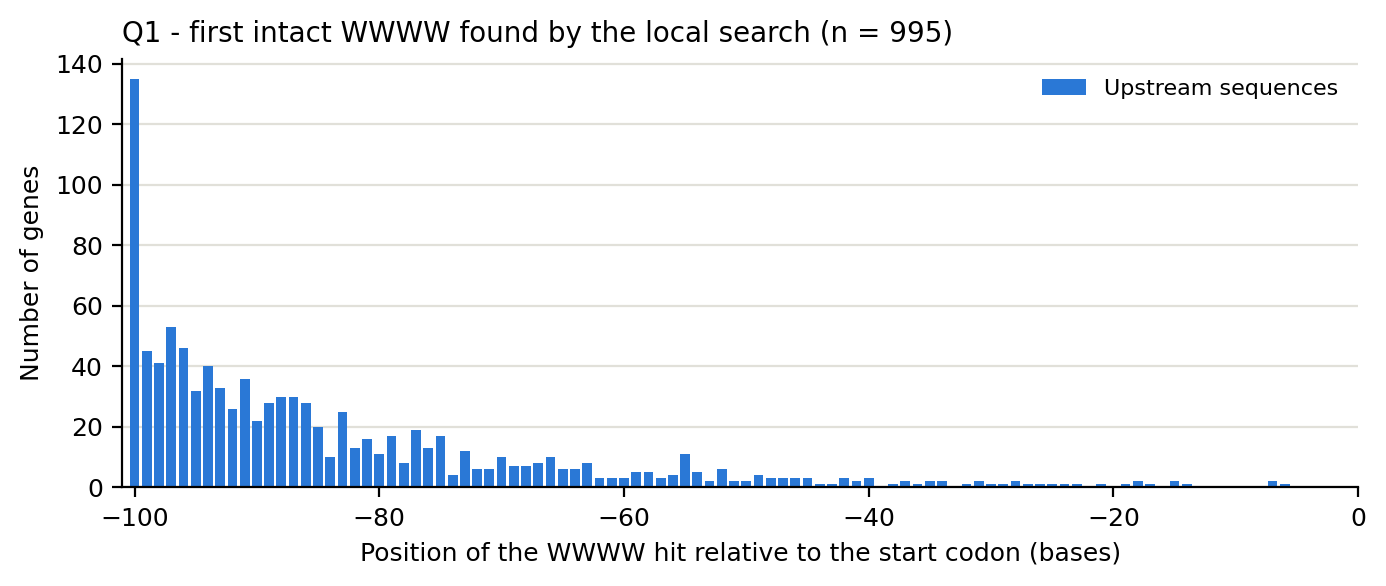

In [7]:
fig = plots.q1_positions(q1)      # quick look (the version with the shuffled curve is saved at the end)

**What I see:** almost every gene has a `WWWW`, and the hits pile up near −100 because the search
reports the first hit and each sequence has about 12 of them.

## Q2 – Number of consecutive Ws

For each hit I count how many A/T bases follow each other from the start of the hit. For random DNA
with A/T probability *p*, the run continues with probability *p* at each base, so the length follows a
geometric distribution: P(L = n) = p<sup>n−4</sup>(1 − p).

In [8]:
q2 = run_q2(d, q1)
pd.DataFrame({"consecutive Ws": list(q2["expected"]),
              "observed": [q2["run_counts"].get(n, 0) for n in q2["expected"]],
              "expected (random)": [round(v, 1) for v in q2["expected"].values()]}).head(11)


Q2 - consecutive Ws
Run length: mean 5.49, median 5, range 4-22
Distribution: {4: 381, 5: 247, 6: 157, 7: 88, 8: 53, 9: 33, 10: 16, 11: 6, 12: 4, 13: 6, 14: 2, 22: 2}
Runs of 8 or more: observed 122, expected for random bases 90
Longest runs: [('chbC', -88, 'AATTAATTATTTTTTAATTTTT'), ('ftnA', -100, 'AATAATTAAATTTAATATTTTA')]


,consecutive Ws,observed,expected (random)
0,4,381,448.6
1,5,247,246.3
2,6,157,135.3
3,7,88,74.3
4,8,53,40.8
5,9,33,22.4
6,10,16,12.3
7,11,6,6.8
8,12,4,3.7
9,13,6,2.0


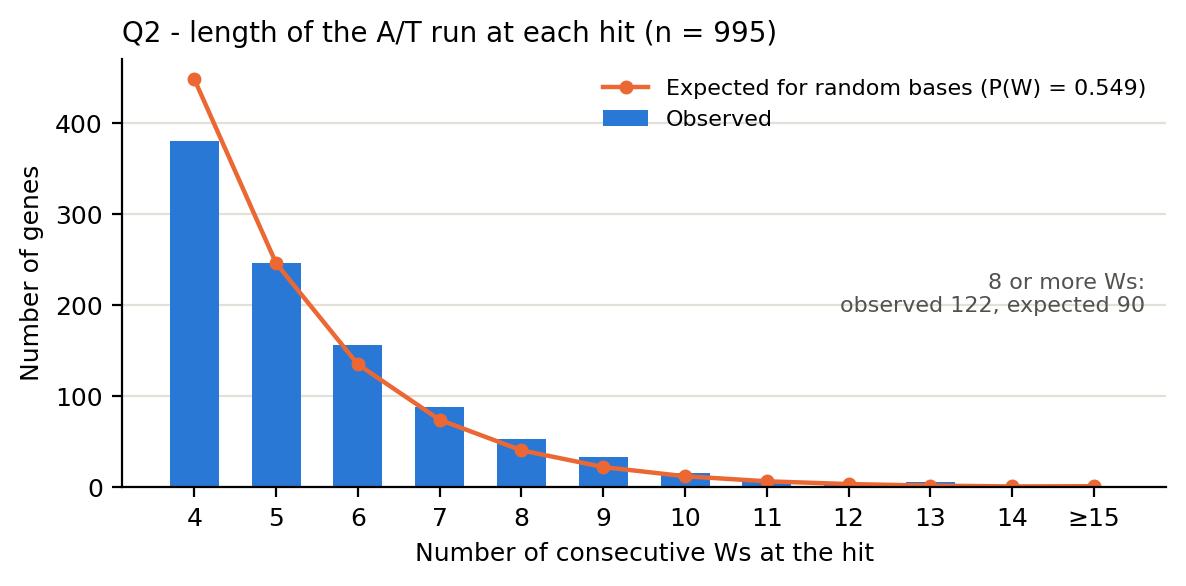

In [9]:
fig = plots.q2_runs(d, q2)

## Q3 – Position probability matrix (PPM)

I take the 6 bases starting at each hit (the Pribnow box is 6 bases long), count each base at each
position and divide by the number of sequences. I add a small pseudocount (0.01) to every count so
that ln(0) never happens in Q4. The information content of a position (in bits) shows how far it is
from random: 0 bits = random, 2 bits = always the same base.

In [10]:
q3 = run_q3(d, q1)
ppm_table = pd.DataFrame(q3["ppm"], index=list(config.BASES), columns=[f"pos{j + 1}" for j in range(config.WINDOW)])
ppm_table.loc["info (bits)"] = q3["info"]
ppm_table.round(3)


Q3 - position probability matrix
Number of 6-base sequences: 995 (239 different)
Most common: [('AAAAAA', 18), ('TTTTTT', 15), ('TTTTTG', 15), ('ATTTTT', 14), ('TTTTGC', 11)]
Frequency matrix (rows A C G T):
[[517 449 483 485 293 268]
 [  0   0   0   0 220 251]
 [  0   0   0   0 161 203]
 [478 546 512 510 321 273]]
PPM:
[[0.52  0.451 0.485 0.487 0.294 0.269]
 [0.    0.    0.    0.    0.221 0.252]
 [0.    0.    0.    0.    0.162 0.204]
 [0.48  0.549 0.515 0.513 0.323 0.274]]
Consensus ATTTTT, consensus score (sum of ln p) = -5.012
Information content per position (bits): [1.001 1.007 1.    1.    0.047 0.009]  total 4.06


,pos1,pos2,pos3,pos4,pos5,pos6
A,0.520,0.451,0.485,0.487,0.294,0.269
C,0.000,0.000,0.000,0.000,0.221,0.252
G,0.000,0.000,0.000,0.000,0.162,0.204
T,0.480,0.549,0.515,0.513,0.323,0.274
info (bits),1.001,1.007,1.000,1.000,0.047,0.009


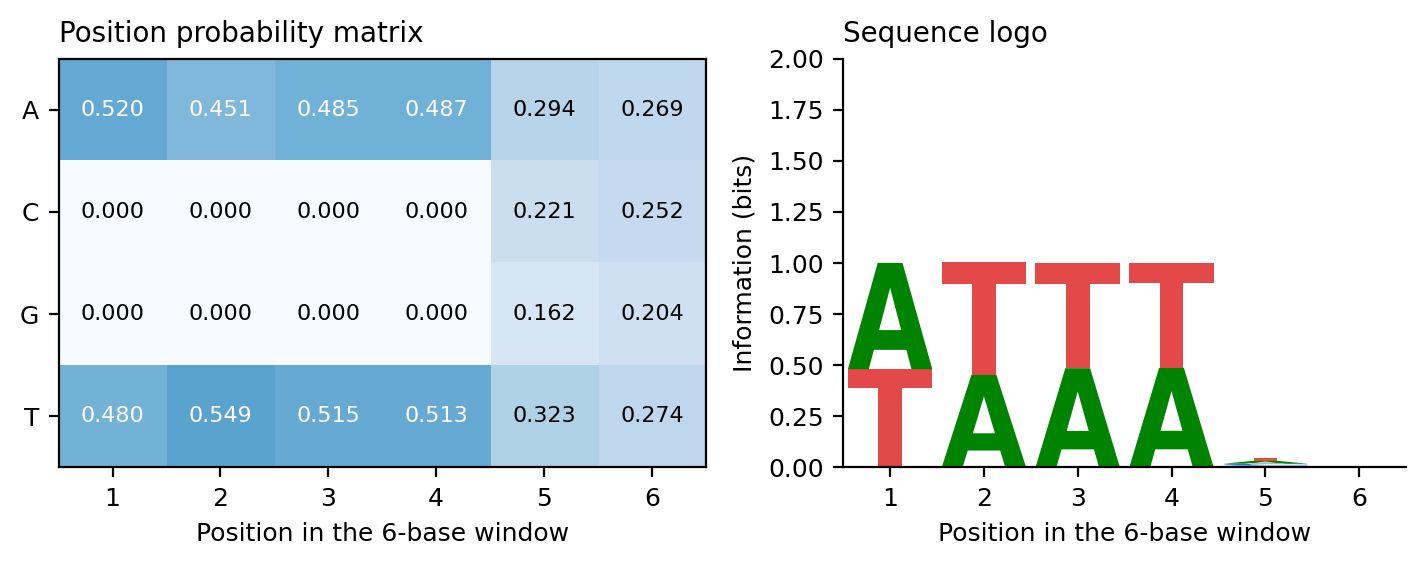

In [11]:
fig = plots.q3_ppm_logo(q3)

## Q4 – Statistical alignment with the PPM

I slide a 6-base window along each upstream sequence (95 windows, from −100 to −6) and give each
window the score S = ln p(base₁, 1) + … + ln p(base₆, 6). This works like a matched filter: the PPM
is the template. The best window is the alignment, and I call a promoter when the best score is
within T of the consensus score (T = −1 … −5). Example on the first sequence:

In [12]:
scores = stat_align(d["upstream"][0], q3["log_ppm"])
best = int(np.argmax(scores))
print("number of windows:", len(scores))
print("best window at position", -(config.UPSTREAM - best), ":", d["upstream"][0][best:best + 6])
print("best score - consensus score =", round(scores.max() - q3["consensus_score"], 3))

number of windows: 95
best window at position -30 : TTTTAC
best score - consensus score = -0.254


In [13]:
q4 = run_q4(d, q1, q3)


Q4 - statistical alignment
Threshold -1: 990/1000 detected (99.0%)
Threshold -2: 995/1000 detected (99.5%)
Threshold -3: 995/1000 detected (99.5%)
Threshold -4: 995/1000 detected (99.5%)
Threshold -5: 995/1000 detected (99.5%)
Best score minus consensus: median -0.127, min -11.19
Scores of the 5 genes without WWWW: [-11.19 -11.13 -11.01 -10.93 -10.9 ]
Position of the best window (T = -2): median -51, IQR -76 to -28
Most common best windows: [('ATTTTT', 113), ('ATTATT', 64), ('ATTTTA', 56), ('TTTTTT', 43), ('ATTTAT', 40)]; windows made only of A/T: 682
Any window starting with WWWW scores at least -1.37 below the consensus


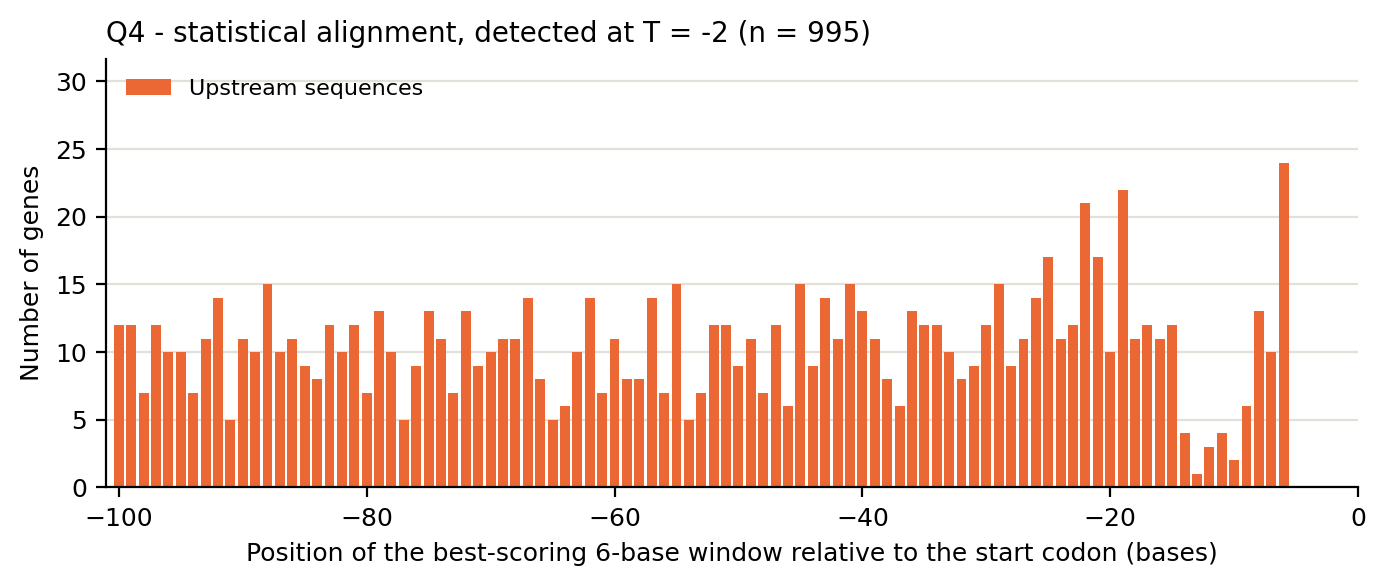

In [14]:
fig = plots.q4_positions(q4)

## Q5 – Comparing the two searches

To know what each search finds **by chance**, I shuffle every upstream sequence 100 times (same
bases, random order) and run both searches again. I compare the positions of the two searches with
the Kolmogorov–Smirnov (KS) test. This step takes a few seconds.

In [15]:
q5 = run_q5(d, q1, q2, q3, q4)


Q5 - comparison
Detected by both: 995; same position 179 (18.0%), within 2 bases 241 (24.2%)
Statistical hit is never upstream of the local hit: True; median shift towards the gene 30 bases
KS test between the two position distributions: D = 0.532, p = 5.06e-129
Mean A/T run at the hit: local 5.49, statistical 6.38


Shuffled: intact WWWW in 97.8% (real 99.5%), 9.7 WWWW per sequence (real 12.2)
Shuffled: statistical detection -1: 96.2%, -2: 97.6%, -3: 97.6%, -4: 97.6%, -5: 97.6%
Shuffled: local-search position median -88, statistical position median -54
  -100 to -26  local  98.6% (shuffled  97.7%)   statistical  77.6% (shuffled  79.1%)
  -25 to -14   local   1.1% (shuffled   1.5%)   statistical  16.1% (shuffled  12.5%)
  -13 to -9    local   0.0% (shuffled   0.4%)   statistical   1.6% (shuffled   5.1%)
  -8 to -6     local   0.3% (shuffled   0.2%)   statistical   4.7% (shuffled   3.2%)


Upstream region overlaps another gene: 466 genes (428 of them right after another + strand gene, like inside an operon)
  WWWW found in 99.1% of these and in 99.8% of the free (intergenic) ones
Random bases with P(W) = 0.549: expected 8.8 WWWW per sequence, P(at least one) = 0.994


In [16]:
c = q5["control"]
pd.DataFrame({
    "Local search (Q1)": [f"{len(q1['found'])} ({len(q1['found']) / 10:.1f}%)", f"{c['found']:.1f}%",
                          f"-{np.median(q1['q1_pos']):.0f}", f"{np.mean(q2['runs']):.1f}"],
    f"Statistical alignment (Q4, T = {config.MAIN_T})": [
        f"{q4['detected'][config.MAIN_T].sum()} ({q4['detected'][config.MAIN_T].mean() * 100:.1f}%)",
        f"{c['det'][config.MAIN_T]:.1f}%", f"-{np.median(q4['det_pos']):.0f}", f"{np.mean(q5['run_at_stat']):.1f}"]},
    index=["genes with a potential promoter", "same test on shuffled sequences",
           "median position of the hit", "mean A/T run at the hit"])

,Local search (Q1),"Statistical alignment (Q4, T = -2)"
genes with a potential promoter,995 (99.5%),995 (99.5%)
same test on shuffled sequences,97.8%,97.6%
median position of the hit,-90,-51
mean A/T run at the hit,5.5,6.4


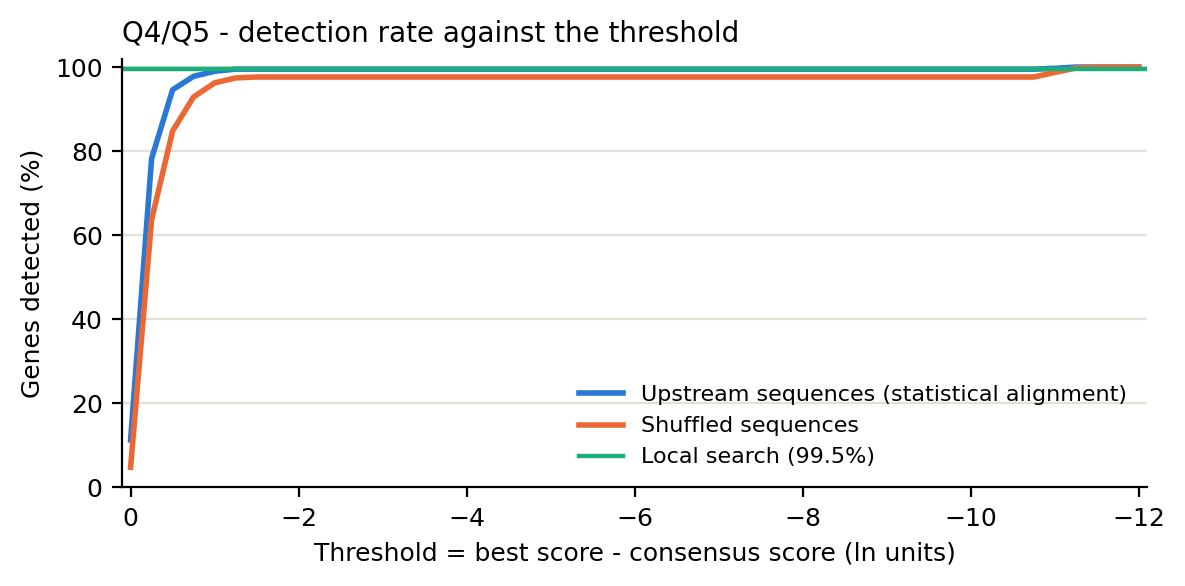

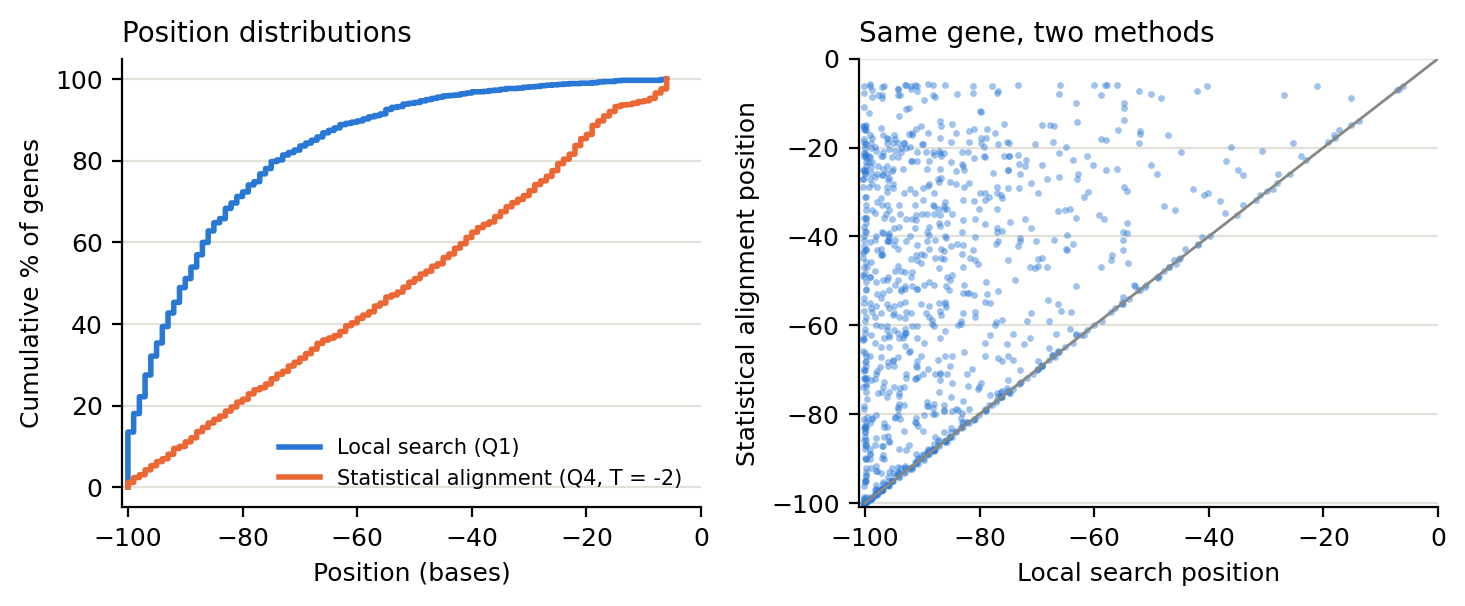

In [17]:
fig1 = plots.q5_threshold(q1, q5)
fig2 = plots.q5_positions(q1, q4, q5)

**What I see:** both searches find a "promoter" in front of almost every gene, but shuffled DNA
gives almost the same percentage, so `WWWW` mostly measures how A/T-rich a sequence is. The two
searches put the hit in different places because the local search reports the first hit while the
statistical alignment reports the best-scoring window.

## Saving the figures and all the numbers

These are the files my report uses.

In [18]:
saved = plots.save_all_figures(d, q1, q2, q3, q4, q5)
summary = build_summary(d, met, q1, q2, q3, q4, q5)
helpers.save_summary(summary)
helpers.save_log()
print("Saved figures:", ", ".join(saved))
print("Saved results/summary.json with", len(summary), "numbers")

Saved figures: fig_Q1_positions.png, fig_Q1_all_occurrences.png, fig_Q2_consecutive_W.png, fig_Q3_PPM_logo.png, fig_Q4_positions.png, fig_Q5_threshold.png, fig_Q5_positions.png
Saved results/summary.json with 81 numbers


In [19]:
# the main numbers in my report
pd.Series({
    "genes with intact WWWW (Q1)": f"{summary['q1_found']} / 1000",
    "median position, local search": f"-{summary['q1_median']:.0f}",
    "mean consecutive Ws (Q2)": f"{summary['q2_mean']:.2f}",
    "PPM consensus (Q3)": summary["q3_consensus"],
    "PPM information (bits)": f"{summary['q3_info_total']:.2f}",
    "detected at T = -1 / -2 (Q4)": f"{summary['q4_detected_percent']['-1']:.1f}% / {summary['q4_detected_percent']['-2']:.1f}%",
    "median position, statistical alignment": f"-{summary['q4_median']:.0f}",
    "same position in both searches": f"{summary['q5_same']} genes",
    "shuffled: WWWW found": f"{summary['shuf_found']:.1f}%",
}, name="value").to_frame()

,value
genes with intact WWWW (Q1),995 / 1000
"median position, local search",-90
mean consecutive Ws (Q2),5.49
PPM consensus (Q3),ATTTTT
PPM information (bits),4.06
detected at T = -1 / -2 (Q4),99.0% / 99.5%
"median position, statistical alignment",-51
same position in both searches,179 genes
shuffled: WWWW found,97.8%


## Conclusion

The local search found an intact `WWWW` in front of 99.5% of the genes, but 97.8% of the shuffled
sequences have one too. The PPM made from the hits (consensus `ATTTTT`) mostly repeats the query,
so the statistical alignment detects the same genes but places the hit somewhere else. My conclusion
is that `WWWW` marks A/T-rich DNA rather than real promoters; a better promoter search would need a
more informative model (for example the full −10 and −35 boxes) and a threshold set against shuffled
DNA. The full discussion is in my report.